# Midterm 1 readiness set

Covers **Lectures 01 through 14**.
There is no new syntax here, only the four ways Wednesday's paper exam will ask about what you already know.

This assignment is graded on completion, not correctness.
A genuine attempt at every lettered part earns full credit for that problem, whether the prediction, the code, or the interpretation turns out right or wrong.
The point is rehearsal for the exam format, not a second midterm.

## Submission instructions

Upload the `ipynb` file to Canvas:
> File -> Download -> ipynb -> upload to Canvas (like any other file)

The `ipynb` file type is the only accepted format.

Save a copy before beginning.
Reloading or disconnecting can revert the notebook to the instructor copy.

# Problem 0 (-10 pts if blank): generative AI usage statement

As you work on this assignment, feel free to use generative AI tools to help you learn,
understand, and debug Python code. In particular, you could get hints or conceptual guidance in
the implementation you write yourself.

However, you must clearly disclose and cite all use of AI. You must include:
1. The name(s) of the AI tool(s) used.
2. The specific prompt(s) you used to generate the content.
3. A description of how you used the output and what edits or additions you made to integrate it
   into your own work.

You are fully responsible for the final submitted work. Critically evaluate, fact-check, and
verify all AI-generated content for validity. Failure to properly cite and disclose AI use
constitutes plagiarism under Penn State's Academic Integrity policy.

Write your disclosure (or "I did not use an AI tool for this assignment") in the cell below.

*your disclosure here*

# Dataset

Wednesday's exam is on paper, with no computer, so this rehearsal reuses data you have already met rather than a new file.
Two databases carry the whole assignment: the tetrahedrite thermoelectric database from Homework 3, and the NIST corrosion database from Monday's lecture.

> Nothing below is new syntax.
> If a line looks unfamiliar, it is worth finding which lecture it came from before Wednesday.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## The corrosion database, filtered to sulfuric acid

Lecture 14 read the full NIST corrosion database and narrowed it to tests run in sulfuric acid with a numeric rate.
The cell below repeats that same filter so `acid` is ready for the rest of this assignment.

In [2]:
#@title Load the NIST corrosion database (click ▶ to run, data loading, not a learning objective) { display-mode: "form" }
import os

import pandas as pd

_file = 'corrosion.csv'
_github = f'https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/{_file}'
_local = next(
    (p for p in (f'datasets/{_file}', f'../datasets/{_file}', f'../../datasets/{_file}',
                 f'../../../datasets/{_file}')
     if os.path.exists(p)),
    None,
)

try:
    table = pd.read_csv(_local if _local else _github)
except Exception as e:
    raise RuntimeError(
        f"Could not load '{_file}'. If you are in Colab, check your internet "
        f"connection and that the file exists at {_github}"
    ) from e

print(f'Loaded {len(table)} corrosion tests from {_file}')
print(f'  {table["Environment"].nunique()} environments, {table["Material Family"].nunique()} material families')

Loaded 24721 corrosion tests from corrosion.csv
  288 environments, 90 material families


In [3]:
is_sulfuric = table['Environment'].to_numpy() == 'Sulfuric Acid'
has_rate = pd.notna(table['rate_mm_yr_numeric']).to_numpy()
acid = table[is_sulfuric & has_rate]

print(len(acid))

1154


`acid['rate_mm_yr_numeric']` is the corrosion rate in mm/yr.
`acid['Material']` names the alloy tested.
`acid['Concentration (Vol %)']` and `acid['Temperature (deg C)']` name the conditions the test ran under, both stored as text.

## The tetrahedrite thermoelectric database

Homework 3 and Lecture 7 both used this file: the highest thermoelectric figure of merit, zT, that each tetrahedrite sample reached.
The cell below loads the full table rather than the plain lists Lecture 7 used, because this assignment also needs the dopant used in each sample.

In [4]:
url = 'https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/thermoelectrics.csv'

te = pd.read_csv(url)
te = te.dropna(subset=['zT_max'])

print(len(te))

278

`te['zT_max']` is the highest zT each sample reached, dimensionless, bigger is better.
`te['dopant_family']` names what the tetrahedrite was doped with.
`te['study_id']` names the publication each sample came from.

# Problem 1 (20 pts): read code, predict the output

On Wednesday you will read code on paper and write down what it prints, with no computer to check yourself.
Write your prediction for each part below before you run the check cell underneath it.

> Reading the check cell's output first only feels like knowing the answer, and it is not the same thing.

(a) What does this print?

```python
radii = np.array([53, 31, 167, 112])
print(radii[1:3])
print(radii[-1])
```

*your answer here*

In [5]:
radii = np.array([53, 31, 167, 112])
print(radii[1:3])
print(radii[-1])

[ 31 167]
112


(b) What does this print?

```python
values = [7.87, 8.96, 2.70]
print(values * 2)
```

*your answer here*

In [6]:
values = [7.87, 8.96, 2.70]
print(values * 2)

[7.87, 8.96, 2.7, 7.87, 8.96, 2.7]


(c) What does this print, or what error does it raise?

```python
record = {'grade': 'A36', 'yield_MPa': 250}
print(record['tensile_MPa'])
```

*your answer here*

In [7]:
# EXPECTED-ERROR: this cell intentionally fails
record = {'grade': 'A36', 'yield_MPa': 250}
print(record['tensile_MPa'])

KeyError: 'tensile_MPa'

(d) What does this print?

```python
tc = np.array([29.0, 88.0, 4.2, 92.0])
mask = tc > 77
print(np.sum(mask))
print(tc[mask])
```

*your answer here*

In [8]:
tc = np.array([29.0, 88.0, 4.2, 92.0])
mask = tc > 77
print(np.sum(mask))
print(tc[mask])

2
[88. 92.]


(e) What does this print?

```python
sample = np.array(['Heo 2014', 1.13, 302])
print(sample.dtype)
print(sample[1] * 2)
```

> This is not an invented example.
> It is one actual row of `te`: a Mn-doped sample from the Heo 2014 study, with `zT_max` 1.13 and `zT_max_temp_C` 302.

*your answer here*

In [9]:
sample = np.array(['Heo 2014', 1.13, 302])
print(sample.dtype)
print(sample[1] * 2)

<U32
1.131.13


# Problem 2 (20 pts): write two to five lines by hand

On Wednesday you will write short code on paper, syntax and all, with no computer to run it against.
These parts use `acid` and `te` from the Dataset section above, already loaded.

(a) Write one line that prints the median of `te['zT_max']`, and one line that prints its interquartile range.

In [10]:
# your code here

(b) Write one line that prints how many samples in `te` reached a `zT_max` above 0.5, and one line that prints what fraction of `te` that is.

In [11]:
# your code here

(c) `table['Rate (mm/yr) or Rating']` came back as dtype `object`, because it mixes numeric rates with letter ratings.
Write one line that would tell you which distinct entries appear in that column.

> `.value_counts()` and `.unique()` both surface this; either is a full-credit answer.

In [12]:
# your code here

(d) Write the three lines that plot `te['zT_max_temp_C']` against `te['zT_max']`, with both axes labelled.

> `plt.show()` is fine as a fourth line and not required.

In [13]:
# your code here

# Problem 3 (25 pts): read the number or the figure

> Two or three sentences is a full answer.
> Naming the statistic that moved, or the population a number describes, is worth more than length.

(a) Run the cell below.
The mean sits well above the median.
In one or two sentences, say which side the long tail is on, and what that says about the tests at that end.

In [14]:
print(f"mean:   {np.mean(acid['rate_mm_yr_numeric']):.2f} mm/yr")
print(f"median: {np.median(acid['rate_mm_yr_numeric']):.2f} mm/yr")

mean:   35.88 mm/yr
median: 0.50 mm/yr


*your answer here*

(b) Run the cell below.
Write the sentence you would put under that number in a report, naming what population it describes.

In [15]:
print(f"{np.percentile(acid['rate_mm_yr_numeric'], 90):.1f} mm/yr")

15.0 mm/yr


*your answer here*

(c) Run the cell below.
`np.mean` on the raw column returns `nan`.
In one sentence, explain why that is the correct answer rather than a failure, and name the function that answers the narrower question about the tests that do report a temperature.

In [16]:
temp_col = pd.to_numeric(acid['Temperature (deg C)'], errors='coerce')

print(np.sum(pd.notna(temp_col)), 'of', len(temp_col), 'tests report a temperature')
print(np.mean(temp_col))

649 of 1154 tests report a temperature
82.7442218798151


*your answer here*

(d) Run the cell below.
Mn reaches the highest single `zT_max` in the whole database.
Se has the higher median.
You can make a handful of samples of one dopant family.
In two or three sentences, say which family you choose, and why.

In [17]:
mn = te[te['dopant_family'] == 'Mn']['zT_max']
se = te[te['dopant_family'] == 'Se']['zT_max']

print(f"Mn: n={len(mn)}  max={np.max(mn):.2f}  median={np.median(mn):.2f}")
print(f"Se: n={len(se)}  max={np.max(se):.2f}  median={np.median(se):.2f}")

Mn: n=16  max=1.13  median=0.64
Se: n=14  max=1.10  median=0.78


*your answer here*

(e) Run the cell below.
It reproduces a figure from Lecture 9, this time with no legend and no colors chosen by material.
In one or two sentences, name two things a reader cannot do with it.

Text(0, 0.5, 'refractive index n')

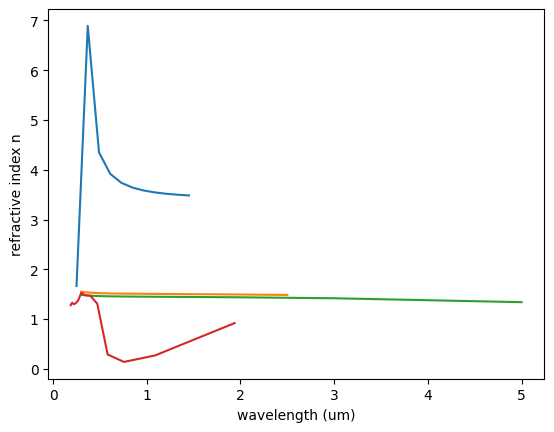

In [18]:
opt_url = 'https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/optical_constants.csv'
opt = pd.read_csv(opt_url)

silicon = opt[opt['material'] == 'silicon']
bk7 = opt[opt['material'] == 'BK7']
fused_silica = opt[opt['material'] == 'fused_silica']
gold = opt[opt['material'] == 'gold']

fig, ax = plt.subplots()
ax.plot(silicon['wavelength_um'], silicon['n'])
ax.plot(bk7['wavelength_um'], bk7['n'])
ax.plot(fused_silica['wavelength_um'], fused_silica['n'])
ax.plot(gold['wavelength_um'], gold['n'])
ax.set_xlabel('wavelength (um)')
ax.set_ylabel('refractive index n')

*your answer here*

# Problem 4 (35 pts): what a result does and does not establish

This part is worth as much as the other three on the exam, and the review packet in class called it the one nobody practices.
Two or three sentences per part is a full answer.

(a) Suppose a lab's median peak solar-cell efficiency rose in each of four successive years of its testing records.
Does that show the technology improved?
In two or three sentences, say what else could explain the rise, and what the data does support.

*your answer here*

(b) Run the cell below.
It uses the 3D-printing file from Homework 4.
In this file, PLA prints come out stronger than ABS prints.

> `prints` is loaded fresh here rather than carried over from Homework 4, since a homework's variables do not persist into the next one.

In [19]:
prints_url = 'https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/3dprinting.csv'
prints = pd.read_csv(prints_url)

pla = prints[prints['material'] == 'pla']
abs_prints = prints[prints['material'] == 'abs']

print(f"PLA: n={len(pla)}  median strength={np.median(pla['tension_strength (Mpa)']):.1f} MPa")
print(f"ABS: n={len(abs_prints)}  median strength={np.median(abs_prints['tension_strength (Mpa)']):.1f} MPa")
print(f"PLA median nozzle temperature: {np.median(pla['nozzle_temperature (degC)']):.0f} degC")
print(f"ABS median nozzle temperature: {np.median(abs_prints['nozzle_temperature (degC)']):.0f} degC")

PLA: n=25  median strength=25.0 MPa
ABS: n=25  median strength=16.0 MPa
PLA median nozzle temperature: 210 degC
ABS median nozzle temperature: 230 degC


In two or three sentences, say what you would need before telling a shop that PLA is the stronger material, and point to one column above that this file does not hold fixed between the two materials.

*your answer here*

(c) Run the cell below.
It counts the distinct raw concentration and temperature entries behind the corrosion medians in Lecture 14.

In [20]:
print(acid['Concentration (Vol %)'].nunique(), 'distinct concentration entries')
print(acid['Temperature (deg C)'].nunique(), 'distinct temperature entries')

107 distinct concentration entries
111 distinct temperature entries


Each alloy's median in Lecture 14 pools every one of those conditions into one number.
In two or three sentences, say what that pooling loses, and what you would report instead so that a plant engineer could use the number for their own tank.

*your answer here*

(d) Run the cell below.
It counts how many samples each study contributed to `te`.

In [21]:
study_counts = te['study_id'].value_counts()

print('smallest study:', np.min(study_counts), 'sample(s)')
print('largest study:', np.max(study_counts), 'samples')
print('number of studies:', len(study_counts))

smallest study: 1 sample(s)
largest study: 11 samples
number of studies: 63


Suppose you pooled every sample in `te` and reported one 90th-percentile `zT_max` for the whole database, the way Homework 3 reported one set of statistics for the whole file.
In two or three sentences, say whose results a pooled percentile like that would mostly reflect, and why.

*your answer here*

# Wrap-up

This assignment carried no new syntax.
It rehearsed the four question types Wednesday's exam uses: reading code without running it, writing short code by hand, reading a single number or figure, and saying what a result does and does not establish.

The corrosion and thermoelectric databases were both already familiar, from Lecture 14 and from Homework 3 and Lecture 7.
Reusing them here is deliberate: the exam rewards recognizing a pattern you have already practiced, not meeting a new dataset cold.

One page of handwritten notes is allowed on Wednesday.
Lecture 14's own list of what to put on that page is still the right list.